In [1]:
print('foo')

foo


In [2]:
from local import *

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

from everest.window import Canvas, DataChannel as Channel, plot
from everest import window
from everest.window.colourmaps import cmap

from analysis import cylindrical

## Varying curvature

In [3]:
isomixed, isointernal, arrmixed, arrinternal = make_frames(refresh=True)

In [4]:
slc = isomixed.loc[0, 1]
slc

f
0.300    877.253561
0.350    855.892568
0.400    839.526121
0.450    826.852155
0.500    816.986847
0.510    815.273285
0.520    813.639069
0.530    812.036896
0.540    810.552216
0.550    809.134674
0.550    809.134882
0.560    807.785797
0.570    806.499481
0.580    805.269623
0.590    804.094696
0.600    802.983856
0.610    801.970673
0.620    800.954437
0.630    799.988556
0.640    799.063873
0.650    798.184967
0.650    798.185372
0.660    797.350311
0.670    796.552277
0.680    795.795441
0.690    795.076752
0.700    794.390106
0.710    793.773651
0.720    793.155670
0.730    792.571259
0.740    792.014313
0.750    791.492601
0.760    790.996552
0.770    790.528107
0.780    790.114594
0.790    789.699554
0.800    789.304352
0.810    788.939667
0.820    788.593292
0.830    788.275909
0.840    787.975311
0.850    787.695617
0.860    787.436676
0.870    787.198639
0.880    786.978912
0.890    786.660004
0.900    786.495209
0.910    786.348724
0.920    786.217499
0.930    786.09695

In [ ]:
sum(map(len, (isomixed, isointernal, arrmixed, arrinternal)))

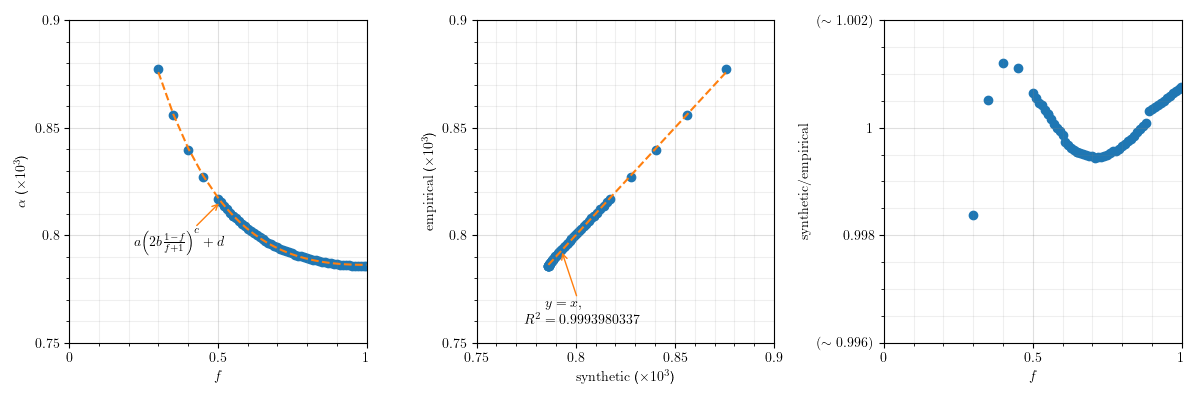

{'a': 83.70874833196282,
 'b': 0.9578401240595349,
 'c': 2.19328476543607,
 'd': 786.2167958645852}

In [5]:
slc = isomixed.loc[0, 1]

canvas = Canvas(size=(12, 4), shape=(1, 3))

def model(x, /, a, b, c, d):
    return a * (b / cylindrical.r_mid(x))**c + d
(*params,), error = curve_fit(model, slc.index, slc.values, (78, 1, 2, 785))
params = dict(zip('abcd', (map(float, params))))
synthetic = model(slc.index, **params)
natural = slc.values
linscore = r2_score(synthetic, natural)

synth_colour = 'tab:orange'

ax1 = canvas.make_ax((0, 0))

xchan = Channel(
    slc.index, label=r"$f$",
    lims=(None, 1.), capped=(None, True),
    )
ax1.scatter(
    xchan,
    Channel(
        natural, label=r"$\alpha$",
        ),
    )
ax1.line(
    xchan,
    Channel(
        synthetic,
        ),
    color=synth_colour,
    linestyle='--',
    )
ax1.annotate(
    xchan.data[5], synthetic[5],
    label = r"$ a {\left( 2b \frac{1-f}{f+1} \right)}^c + d $",
    points = (-30, -30),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

ax2 = canvas.make_ax((0, 1))

ax2.scatter(
    Channel(synthetic, label=r"$\mathrm{synthetic}$"),
    Channel(natural, label=r"$\mathrm{empirical}$"),
    )

ax2.line(
    vals := np.linspace(np.min(synthetic), np.max(synthetic), 10), vals,
    color = synth_colour, linestyle = '--',
    )
ax2.annotate(
    *(map(np.median, (synthetic, natural))),
    label = f"${r'y=x, \\ R^2 =' + str(round(linscore, 10))}$",
    points = (15, -45),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

ax3 = canvas.make_ax((0, 2))

ax3.scatter(
    xchan,
    Channel(
        synthetic / natural, label=r"$\mathrm{synthetic} / \mathrm{empirical}$",
        )
    )


display(canvas)
display(params)

## Varying aspect ratio

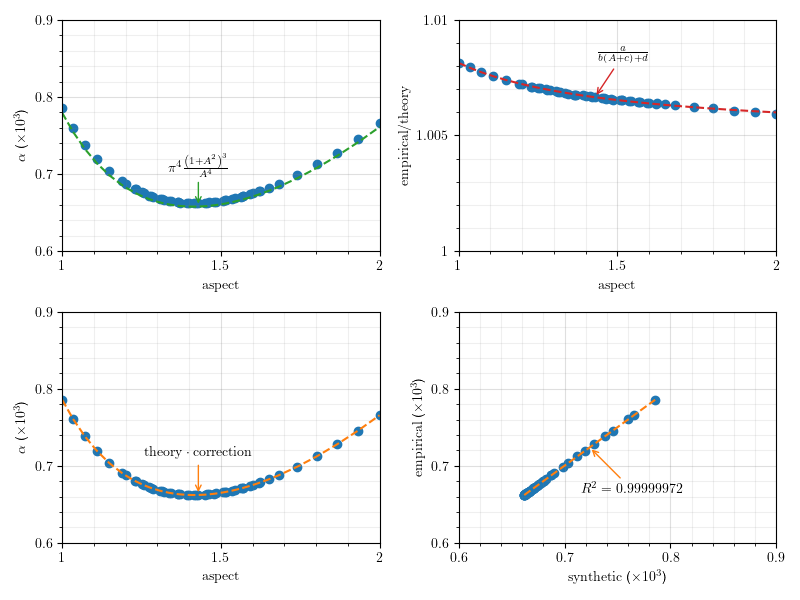

[np.float64(0.0018329052407802255),
 np.float64(1.1486063069267571),
 np.float64(-0.5023862168295954),
 np.float64(1.004931227132051)]

In [6]:
slc = isomixed.loc[0, :, 0.999]
# slc = arrmixed[0, :, 1., 0.999]

crit_func = lambda A: math.pi**4 * (1 + A**2)**3 / A**4
independent = slc.index
empirical = slc.values
theory = tuple(map(crit_func, slc.index))
discrepancy = empirical / theory

canvas = Canvas(size = (8, 6), shape = (2, 2))

synth_colour = 'tab:orange'

ax1 = canvas.ax((0, 0))
ax1.scatter(
    xchan := Channel(
        independent, label=r"$\mathrm{aspect}$",
        ),
    ychan := Channel(empirical, label=r"$\alpha$", log=False),
    )
ax1.line(
    xchan,
    Channel(theory, log=False),
    linestyle='--',
    color="tab:green"
    )
midpoint = round(len(theory) / 2)
ax1.annotate(
    xchan.data[midpoint], theory[midpoint],
    label = r"$\pi^4 \frac{{\left(1+A^2\right)}^3}{A^4}$",
    points = (0, 30),
    arrowprops = dict(arrowstyle = "->", color = "tab:green"),
    )

# ax1.props.edges.x.label.visible = False
# ax1.props.edges.x.ticks.major.labels = ()
# ax1.props.edges.x.swap()
# ax1.props.edges.x.ticks.major.labels[:] = []

def crit_aspect_correction_func(x, /, a, b, c, d):
    return a / (b*(x + c)) + d
(*params,), error = \
    curve_fit(crit_aspect_correction_func, slc.index, discrepancy)
crit_aspect_correction_params = dict(zip('abcd', (map(float, params))))
crit_aspect_correction = \
    lambda x: crit_aspect_correction_func(x, **crit_aspect_correction_params)

correction = crit_aspect_correction(slc.index)

ax2 = canvas.ax((0, 1))
ax2.scatter(
    xchan,
    Channel(discrepancy, label=r'$\mathrm{empirical} / \mathrm{theory}$'),
    )
ax2.line(
    xchan,
    Channel(correction),
    linestyle='--',
    color="tab:red",
    )
ax2.annotate(
    xchan.data[midpoint], correction[midpoint],
    # label = f"$ \\frac{{ {params['a']} }}{{ {params['b']} \\left( x + {params['c']} \\right) }} + {params['d']} $",
    label = r"$\frac{a}{b \left(A+c\right) + d}$",
    points = (20, 30),
    arrowprops = dict(arrowstyle = "->", color = "tab:red"),
    )

# ax2.props.edges.x.label.visible = False
# ax2.props.edges.x.ticks.major.labels = ()

crit_aspect_synthetic = lambda x: crit_func(x) * crit_aspect_correction(x)

synthetic = crit_aspect_synthetic(slc.index)

ax3 = canvas.ax((1, 0))
ax3.scatter(
    xchan,
    ychan,
    )
ax3.line(
    xchan,
    Channel(synthetic, log=False),
    linestyle='--',
    color=synth_colour,
    )
ax3.annotate(
    xchan.data[midpoint], synthetic[midpoint],
    label = r"$\mathrm{theory} \cdot \mathrm{correction}$",
    points = (0, 30),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

ax4 = canvas.ax((1, 1))
ax4.scatter(
    Channel(synthetic, label=r"$\mathrm{synthetic}$"),
    Channel(empirical, label=r"$\mathrm{empirical}$"),
    )
linscore = r2_score(synthetic, empirical)
ax4.line(
    Channel(np.linspace(min(synthetic), max(synthetic), 100)),
    Channel(np.linspace(min(empirical), max(empirical), 100)),
    linestyle = '--',
    color=synth_colour,
    )
ax4.annotate(
    *map(window.utilities.median, (synthetic, empirical)),
    label = f"${'R^2 =' + str(round(linscore, 9))}$",
    points = (30, -30),
    arrowprops = dict(arrowstyle = "->", color = synth_colour),
    )

display(canvas)
display(params)

## Varying both curvature and aspect ratio

aspect  f    
1.0     0.300    877.253561
        0.350    855.892568
        0.400    839.526121
        0.450    826.852155
        0.500    816.986847
                    ...    
2.0     0.960    765.653229
        0.970    765.628815
        0.980    765.593719
        0.990    765.550995
        0.999    765.505219
Name: alpha, Length: 1061, dtype: float64

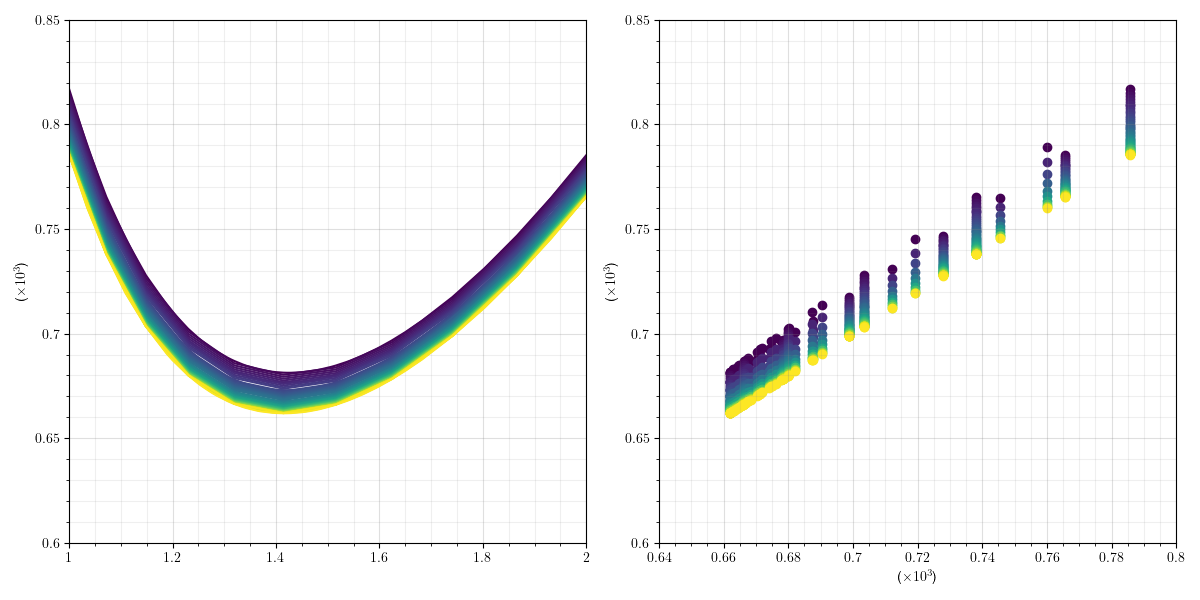

In [7]:
slc = isomixed[0.]
display(slc)

canvas = Canvas(size=(12, 6), shape=(1, 2))

ax1 = canvas.make_ax()
fvals = tuple(sorted(
    val for val in set(slc.index.get_level_values('f'))
    if val >= 0.5
    ))
for fval in fvals:
    subslc = slc[:, fval].sort_index()
    ax1.line(
        subslc.index, subslc.values,
        color=cmap(fval, fvals, style = 'viridis'),
        )

ax2 = canvas.make_ax((0, 1))
for fval in fvals:
    # if fval != 0.5:
    #     continue
    subslc = slc[:, fval].sort_index()
    ax2.scatter(
        crit_aspect_synthetic(subslc.index), subslc.values,
        color=cmap(fval, fvals, style = 'viridis'),
        )

canvas

In [ ]:
slc = isomixed[0.]
display(slc)

canvas = Canvas(size=(12, 6), shape=(1, 1))

ax1 = canvas.make_ax()
fvals = tuple(sorted(
    val for val in set(slc.index.get_level_values('f'))
    if val >= 0.5
    ))
for fval in fvals:
    subslc = slc[:, fval].sort_index()
    ax1.line(
        subslc.index, subslc.values,
        color=cmap(fval, fvals, style = 'viridis'),
        )

canvas

In [ ]:
slc = isomixed[0, :, 0.5]
display(slc)

canvas = Canvas(size=(12, 12))
ax = canvas.make_ax()
ax.scatter(
    chanx := Channel(crit_aspect_synthetic(slc.index)),
    chany := Channel(slc.values),
    c=slc.index,
    )
for x, y, z in zip(chanx.data, chany.data, slc.index):
    ax.annotate(x, y, round(z, 2))
canvas

In [ ]:
slc.index

In [ ]:
grpby = slc.groupby('f')
grpby.max() - grpby.min()

In [ ]:
crit_func(subslc.values)

## Varying heat input

In [ ]:
isomixed

In [ ]:
slc = isomixed[:, 1., 0.999][:]

In [ ]:
canvas = Canvas(size=(6, 6))
ax1 = canvas.make_ax()

ax1.scatter(
    Channel(slc.index, lims=(0, 5)),
    slc.values,
    )

canvas

In [ ]:
(0.5, 0.75, 1.25, 1.5, 1.75, 2, 2.25, 2.75, 3, 3.25, 3.5, 3.75)